In [1]:
!pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 KB 5.6 MB/s eta 0:00:00a 0:00:01


In [2]:
# Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import pickle

In [3]:
# Load dataset

df = pd.read_csv("DelhiHousePrice.csv")

# Show first 5 rows
df.head()

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0


In [4]:
# Check dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area         1259 non-null   float64
 1   BHK          1259 non-null   int64  
 2   Bathroom     1257 non-null   float64
 3   Furnishing   1254 non-null   object 
 4   Locality     1259 non-null   object 
 5   Parking      1226 non-null   float64
 6   Price        1259 non-null   int64  
 7   Status       1259 non-null   object 
 8   Transaction  1259 non-null   object 
 9   Type         1254 non-null   object 
 10  Per_Sqft     1018 non-null   float64
dtypes: float64(4), int64(2), object(5)
memory usage: 108.3+ KB


In [5]:
# Check missing values

df.isnull().sum()

Area             0
BHK              0
Bathroom         2
Furnishing       5
Locality         0
Parking         33
Price            0
Status           0
Transaction      0
Type             5
Per_Sqft       241
dtype: int64

In [6]:
# Remove missing values

df = df.dropna()

# Verify again
df.isnull().sum()

Area           0
BHK            0
Bathroom       0
Furnishing     0
Locality       0
Parking        0
Price          0
Status         0
Transaction    0
Type           0
Per_Sqft       0
dtype: int64

In [7]:
# Statistical summary

df.describe()

,Area,BHK,Bathroom,Parking,Price,Per_Sqft
count,1005.000000,1005.000000,1005.000000,1005.000000,1.005000e+03,1005.000000
mean,1504.301968,2.791045,2.575124,1.697512,2.224030e+07,15663.630846
std,1729.104830,0.961469,1.088503,3.223118,2.771744e+07,21170.160448
min,28.000000,1.000000,1.000000,1.000000,1.000000e+06,1259.000000
25%,770.000000,2.000000,2.000000,1.000000,5.130000e+06,6364.000000
50%,1150.000000,3.000000,2.000000,1.000000,1.400000e+07,11363.000000
75%,1700.000000,3.000000,3.000000,2.000000,2.700000e+07,18000.000000
max,24300.000000,7.000000,7.000000,39.000000,2.400000e+08,183333.000000


In [8]:
# Convert categorical columns into numeric

df = pd.get_dummies(df, drop_first=True)

# Check updated dataset

df.head()

,Area,BHK,Bathroom,Parking,Price,Per_Sqft,Furnishing_Semi-Furnished,Furnishing_Unfurnished,"Locality_Abhimanyu Apartments, Vasundhara Enclave","Locality_Abul Fazal Enclave Part 1, Okhla",...,"Locality_Vinoba Puri, Lajpat Nagar","Locality_Virat Residency, Dwarka Mor","Locality_Vishwas Nagar, Shahdara","Locality_Yamuna Apartment, Alaknanda","Locality_Yamuna Vihar, Shahdara","Locality_Zakir Nagar, New Friends Colony","Locality_mind. The space is airy, is well located and can be easily customized as per the needs. Prime facilities are easily accessible from this place with Government Girls Senior Secondary School No 2 (0 km ). Other key neighbourhood are B Block Market (0 km ). read more Contact Owner View Phone No. Share Feedback Owner vinod kumar",Status_Ready_to_move,Transaction_Resale,Type_Builder_Floor
1,750.0,2,2.0,1.0,5000000,6667.0,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,950.0,2,2.0,1.0,15500000,6667.0,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
3,600.0,2,2.0,1.0,4200000,6667.0,True,False,False,False,...,False,False,False,False,False,False,False,True,True,True
4,650.0,2,2.0,1.0,6200000,6667.0,True,False,False,False,...,False,False,False,False,False,False,False,True,False,True
5,1300.0,4,3.0,1.0,15500000,6667.0,True,False,False,False,...,False,False,False,False,False,False,False,True,False,True


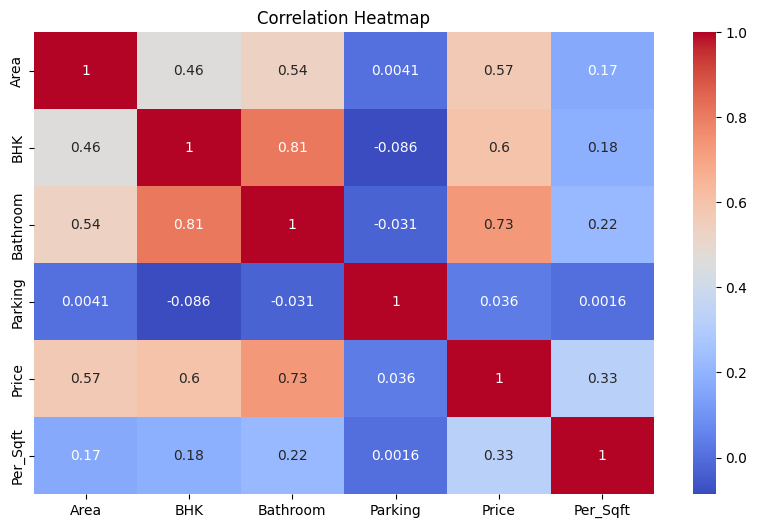

In [9]:
# Correlation heatmap 

plt.figure(figsize=(10,6))

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Limit to first 10 columns to avoid slow plotting
sns.heatmap(
    numeric_df.corr().iloc[:10, :10],
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [10]:
# Define X and y

X = df.drop("Price", axis=1)

y = df["Price"]

In [11]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
# Train Linear Regression model

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
# Predict values

y_pred = model.predict(X_test)

In [14]:
# Model evaluation

print("R2 Score:", r2_score(y_test, y_pred))

print("MAE:", mean_absolute_error(y_test, y_pred))

print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.5992364470518539
MAE: 11975074.07723654
MSE: 348636830487534.75


In [15]:
# Save model using pickle

pickle.dump(
    model,
    open("delhi_house_model.pkl", "wb")
)

print("Model saved successfully!")

Model saved successfully!


In [16]:
# Save model
pickle.dump(model, open("delhi_house_model.pkl", "wb"))

# Save feature column names
pickle.dump(X.columns, open("model_columns.pkl", "wb"))

print("Model and columns saved successfully!")

Model and columns saved successfully!
